# Project REXIA

# Image data

## Imports et préliminaires

In [10]:
import os

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import lime
from lime import lime_image
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
#import data
DATA_PATH = "./data/celeba-dataset"

In [12]:
df_attributes = pd.read_csv(os.path.join(DATA_PATH, "list_attr_celeba.csv"))
df_bbox = pd.read_csv(os.path.join(DATA_PATH, "list_bbox_celeba.csv"))
df_eval_partitions = pd.read_csv(os.path.join(DATA_PATH, "list_eval_partition.csv"))
df_landmarks = pd.read_csv(os.path.join(DATA_PATH, "list_landmarks_align_celeba.csv"))

## Analyse du jeu de données

### Analyse descriptive

Data Files

- img_align_celeba.zip: All the face images, cropped and aligned 
list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing 
- list_bbox_celeba.csv: Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box
- list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth 
- list_attr_celeba.csv: Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative

In [4]:
print(df_attributes.shape)  # 202599 pictures and 41 attributes (including the image name) 
display(df_attributes.head())              
print(f"List of attributes : {df_attributes.columns.tolist()}")            
print("----------------------------------")
print("Number of positives per attribute:") 
display((df_attributes == 1).sum())
print("----------------------------------")
print(f"Average number of positives accrosss all attributes: {(df_attributes == 1).mean() } ")

(202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


List of attributes : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
----------------------------------
Number of positives per attribute:


image_id                    0
5_o_Clock_Shadow        22516
Arched_Eyebrows         54090
Attractive             103833
Bags_Under_Eyes         41446
Bald                     4547
Bangs                   30709
Big_Lips                48785
Big_Nose                47516
Black_Hair              48472
Blond_Hair              29983
Blurry                  10312
Brown_Hair              41572
Bushy_Eyebrows          28803
Chubby                  11663
Double_Chin              9459
Eyeglasses              13193
Goatee                  12716
Gray_Hair                8499
Heavy_Makeup            78390
High_Cheekbones         92189
Male                    84434
Mouth_Slightly_Open     97942
Mustache                 8417
Narrow_Eyes             23329
No_Beard               169158
Oval_Face               57567
Pale_Skin                8701
Pointy_Nose             56210
Receding_Hairline       16163
Rosy_Cheeks             13315
Sideburns               11449
Smiling                 97669
Straight_H

----------------------------------
Average number of positives accrosss all attributes: image_id               0.000000
5_o_Clock_Shadow       0.111136
Arched_Eyebrows        0.266981
Attractive             0.512505
Bags_Under_Eyes        0.204572
Bald                   0.022443
Bangs                  0.151575
Big_Lips               0.240796
Big_Nose               0.234532
Black_Hair             0.239251
Blond_Hair             0.147992
Blurry                 0.050899
Brown_Hair             0.205194
Bushy_Eyebrows         0.142168
Chubby                 0.057567
Double_Chin            0.046688
Eyeglasses             0.065119
Goatee                 0.062764
Gray_Hair              0.041950
Heavy_Makeup           0.386922
High_Cheekbones        0.455032
Male                   0.416754
Mouth_Slightly_Open    0.483428
Mustache               0.041545
Narrow_Eyes            0.115149
No_Beard               0.834940
Oval_Face              0.284143
Pale_Skin              0.042947
Pointy_Nose     

<Axes: ylabel='None'>

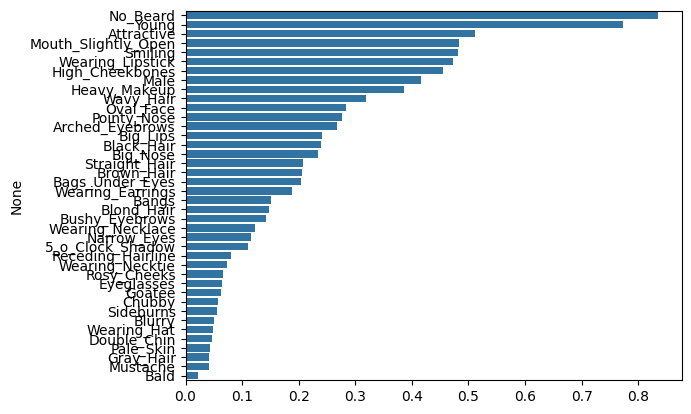

In [5]:
positive_rate = (df_attributes.drop('image_id', axis=1) == 1).mean().sort_values(ascending=False)
sns.barplot(x=positive_rate.values, y=positive_rate.index)

In [6]:
attr_cols = df_attributes.columns[1:]  # all columns except 'image_id'
df_eval_partitions['partition'].value_counts()    # 0=train, 1=val, 2=test
# puis merge avec les attributs pour vérifier que la distribution est homogène
merged = df_attributes.merge(df_eval_partitions, on='image_id')
merged.groupby('partition')[attr_cols].mean()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
partition,,,,,,,,,,,,,,,,,,,,,
0,-0.776654,-0.468231,0.027253,-0.591079,-0.954377,-0.696689,-0.518179,-0.528894,-0.521951,-0.701825,...,-0.887498,-0.040609,-0.582884,-0.361283,-0.626934,-0.901223,-0.060797,-0.757154,-0.853904,0.557879
1,-0.763930,-0.483163,0.040117,-0.585141,-0.958625,-0.706549,-0.693562,-0.502391,-0.582826,-0.692354,...,-0.862385,-0.033372,-0.588765,-0.446821,-0.618563,-0.905371,-0.108069,-0.758796,-0.854734,0.493129
2,-0.800220,-0.431119,-0.008316,-0.594730,-0.957619,-0.688508,-0.345957,-0.575994,-0.456768,-0.733494,...,-0.907224,0.000601,-0.580202,-0.271917,-0.586715,-0.915940,0.043783,-0.724176,-0.859834,0.514277


### Analyse des corrélations

<Axes: >

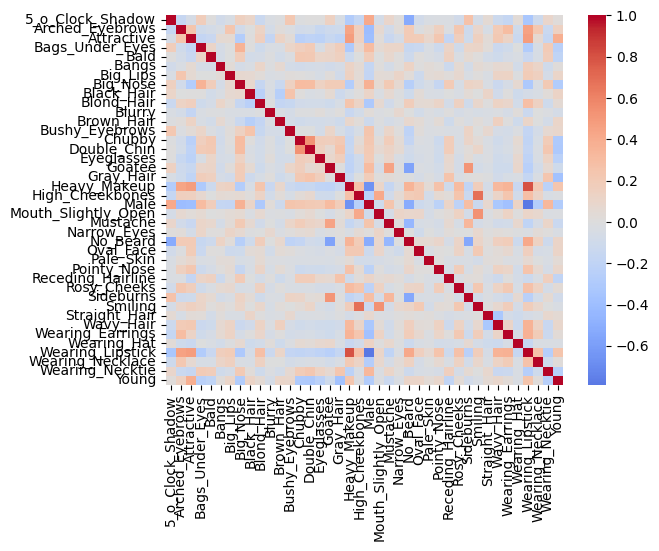

In [7]:
df_binary = (df_attributes[attr_cols] == 1).astype(int)
corr_matrix = df_binary.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)

In [8]:
# Extraire le triangle supérieur sans la diagonale
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .sort_values(ascending=False))

corr_pairs.head(15)   # plus corrélées positivement
corr_pairs.tail(15)   # plus corrélées négativement

Double_Chin       Young              -0.309809
Straight_Hair     Wavy_Hair          -0.321452
Male              Wavy_Hair          -0.323983
5_o_Clock_Shadow  Wearing_Lipstick   -0.333921
Gray_Hair         Young              -0.364466
Male              Wearing_Earrings   -0.373469
Attractive        Male               -0.394451
Arched_Eyebrows   Male               -0.408016
Mustache          No_Beard           -0.452595
Male              No_Beard           -0.522243
5_o_Clock_Shadow  No_Beard           -0.526946
No_Beard          Sideburns          -0.543061
Goatee            No_Beard           -0.570071
Heavy_Makeup      Male               -0.666724
Male              Wearing_Lipstick   -0.789435
dtype: float64

#### Corrélations artificielles

Deux variables sont artificiellement corrélées quand leur forte corrélation statistique entre deux variables qui n'ont pas de lien causal directs mais résulte d'un troisième facteur.

**Wearing_Lipstick <-> Male** : forte corrélation négative, mais causée par le genre comme variable confondante - ce n'est pas que le rouge à lèvres cause d'être femme, c'est que les deux co-occurrent dans les données de collecte.

**Heavy_Makeup <-> Attractive** : corrélées positivement, mais le lien est biaisé par les standards de beauté présents dans les annotations humaines.

<Axes: >

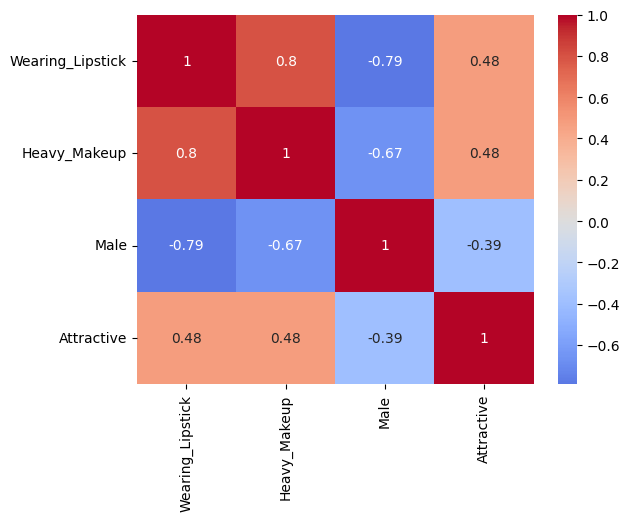

In [9]:
# tableau croisé
pd.crosstab(df_binary['Wearing_Lipstick'], df_binary['Male'], normalize='index')
# ou un heatmap de la sous-matrice
sns.heatmap(df_binary[['Wearing_Lipstick', 'Heavy_Makeup', 'Male', 'Attractive']].corr(),
            annot=True, cmap='coolwarm', center=0)

### Identification de variables sensibles

La justification de la sensibilité d'une variable repose sur trois critères : **caractéristique protégée** (genre, couleur de peau, âge = protégés par la loi en France/UE), **risque de discrimination** si utilisée dans un modèle, et **déséquilibre de représentation**. Par exemple Pale_Skin n'est pas directement un attribut légalement protégé mais il est un proxy de l'origine ethnique - ce qui le rend sensible.

In [10]:
sensitive = ['Male', 'Pale_Skin', 'Young']
(df_binary[sensitive] == 1).mean()   # taux de présence dans le dataset

Male         0.416754
Pale_Skin    0.042947
Young        0.773617
dtype: float64

### Analyse de disparité

Pale_Skin,0,1
Male,,
0,0.550447,0.032799
1,0.406606,0.010148


<Axes: >

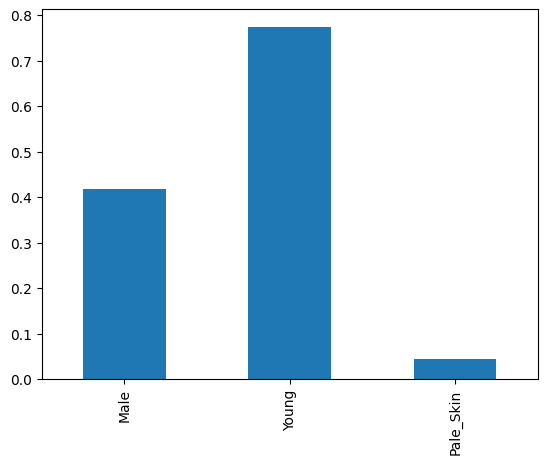

In [11]:
# Distribution de Male
df_binary['Male'].value_counts(normalize=True)

# Croisement de deux attributs sensibles
display(pd.crosstab(df_binary['Male'], df_binary['Pale_Skin'], normalize='all'))

# Pour visualiser plusieurs groupes simultanément
group_cols = ['Male', 'Young', 'Pale_Skin']
df_binary[group_cols].mean().plot(kind='bar')

biais de représentativité : 55% de femmes à la peau pâle.

In [12]:
# Combinaisons rares
df_binary.groupby(['Male', 'Pale_Skin', 'Young']).size().sort_values()

Male  Pale_Skin  Young
1     1          0          483
0     1          0          739
1     1          1         1573
0     1          1         5906
      0          0        14139
1     0          0        30504
                 1        51874
0     0          1        97381
dtype: int64

### Analyse de la fairness

In [13]:
def fairness_metrics(df, sensitive_attr, target_attr):
    groups = df.groupby(sensitive_attr)[target_attr].mean()
    # groups[1]  = P(Y=1 | S=1)
    # groups[0]  = P(Y=1 | S=-1)  (on a converti -1 → 0 avant)
    
    p_s1 = groups[1]
    p_s0 = groups[0]
    
    demographic_parity = abs(p_s1 - p_s0)
    disparate_impact   = p_s1 / p_s0 if p_s0 > 0 else np.nan
    
    return {'demographic_parity': demographic_parity,
            'disparate_impact': disparate_impact}

## Apprentissage automatique

Le but de cette section est d'entraîner un modèle de classification binaire pour prédire l'attribut "Smiling" à partir des images du dataset.

Deux options ont été étudiées : un modèle entraîné sur les images entières, un autre entraîné uniquement sur la région de la bouche (en utilisant les coordonnées de bounding box).

La cellule ci-dessous permet d'extraire et enregistrer les images de la bouche à partir des images entières, en utilisant les coordonnées de bounding box fournies dans le dataset.

In [ ]:
from lips_extraction import extract_and_save_lips

src_folder = os.path.join(DATA_PATH, "img_align_celeba/img_align_celeba")
output_dir = os.path.join(DATA_PATH, "lips_crops")

# Uncomment if you want to extract the lips crops (this can take a while)
# extract_and_save_lips(df_landmarks, output_dir, src_folder, n_workers=8, margin=0.2)

Cropping images: 100%|██████████| 202599/202599 [02:11<00:00, 1543.38it/s]


Done. 202599/202599 images saved to './data/celeba-dataset/lips_crops/'.


[]

Le dataset est ensuite chargé dans un DataLoader PyTorch pour l'entraînement du modèle, et est séparé grâce à la partition recommandée dans le fichier list_eval_partition.csv.

In [13]:
from models.images.dataset import CelebASmilingDataset, IMGNET_MEAN, IMGNET_STD

img_dir_all = os.path.join(DATA_PATH, "img_align_celeba/img_align_celeba")
img_dir_lips = os.path.join(DATA_PATH, "lips_crops")

train_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=0)
val_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=1)
test_dataset_all = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_all, partition=2)

train_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=0)
val_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=1)
test_dataset_lips = CelebASmilingDataset(df_attributes, df_eval_partitions, img_dir_lips, partition=2)

print(f"Number of samples in train/val/test (all images) : {len(train_dataset_all)}/{len(val_dataset_all)}/{len(test_dataset_all)}")
print(f"Number of samples in train/val/test (lips crops) : {len(train_dataset_lips)}/{len(val_dataset_lips)}/{len(test_dataset_lips)}")

Number of samples in train/val/test (all images) : 162770/19867/19962
Number of samples in train/val/test (lips crops) : 162770/19867/19962


In [14]:
from torch.utils.data import DataLoader

train_all_loader = DataLoader(train_dataset_all, batch_size=64, shuffle=True)
val_all_loader = DataLoader(val_dataset_all, batch_size=64, shuffle=False)
test_all_loader = DataLoader(test_dataset_all, batch_size=64, shuffle=False)

train_lips_loader = DataLoader(train_dataset_lips, batch_size=64, shuffle=True)
val_lips_loader = DataLoader(val_dataset_lips, batch_size=64, shuffle=False)
test_lips_loader = DataLoader(test_dataset_lips, batch_size=64, shuffle=False)

### Choix du modèle et entraînement

Pour ce modèle de classificatio binaire, nous avons choisi de partir d'un modèle pré-entrainé sur ImageNet: MobileNetV3 Small qui a l'avantage d'être léger et rapide à entraîner. Nous avons remplacé la dernière couche de classification par une couche linéaire à 1 sortie pour la classification binaire, et freezé les autres couches pour ne pas les entraîner.

In [15]:
%load_ext autoreload
%autoreload 2
%aimport -google.protobuf
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

def get_mobilenet(freeze_backbone: bool = True) -> nn.Module:
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    return model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Explications post-hoc

> Lime Shapley

In [ ]:
import mlflow
from models.images.model import train

# ── Entry point ───────────────────────────────────────────────────────────────
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("celeba-smiling")

model   = get_mobilenet(freeze_backbone=True)
results = train(
    model, train_all_loader, val_all_loader, test_all_loader,
    n_epochs=5, lr=1e-3, patience=3, run_name="mobilenetv3-baseline-all"
)

[Train] Epoch 01 | Loss 0.2871 | Acc 0.767 | F1 0.752 | AUC 0.846 | Prec 0.770 | Rec 0.734 | Spec 0.798


[Val] Epoch 01 | Loss 0.2776 | Acc 0.788 | F1 0.786 | AUC 0.875 | Prec 0.767 | Rec 0.806 | Spec 0.771
  ✓ New best val AUC: 0.8745 — weights saved.



train epoch 2:  49%|████▉     | 1259/2544 [13:34<19:17,  1.11it/s, loss=0.2813, acc=0.788, f1=0.770]

In [16]:
model = get_mobilenet()
state_dict = torch.load("models/model-weights/model-smiling-mobilev3-crop.pth")
model.load_state_dict(state_dict)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = model.to(device)

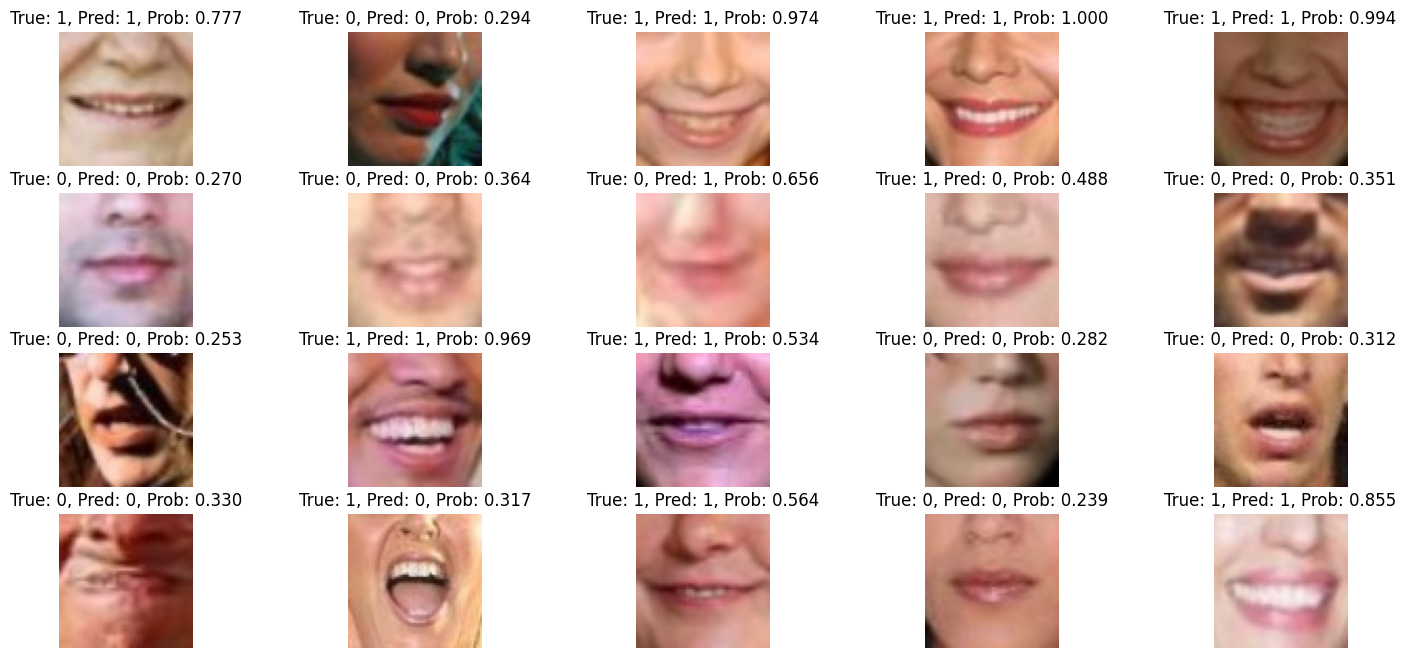

In [58]:
# Make classification on n=10 samples from the test set with image plot
model.eval()
n = 20
fig = plt.figure(figsize=(18, 8))
axs = fig.subplots(4, 5)
axs = axs.flatten()

with torch.no_grad():
    for i, (images, labels) in enumerate(test_lips_loader):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()

        for j in range(min(n, images.size(0))):
            img = images[j].cpu().permute(1, 2, 0).numpy() * np.array(IMGNET_STD) + np.array(IMGNET_MEAN)
            axs[j].imshow(np.clip(img, 0, 1))
            axs[j].set_title(f"True: {labels[j].item():.0f}, Pred: {preds[j].item():.0f}, Prob: {probs[j].item():.3f}")
            axs[j].axis('off')
        break

plt.show()

### Évaluation de l'équité

In [117]:
from tqdm import tqdm

sensitive_attr = ["Male", "Pale_Skin", "Young"]

### Comparaison de l'accuracy par groupe sensible
def evaluate_by_group(model:nn.Module, dataloader:CelebASmilingDataset, sensitive_attr:list[str]):
    raw_data = dict(zip(sensitive_attr, np.zeros((len(sensitive_attr), 2, 4), dtype=int)))  # group -> group_value -> [TP, FP, TN, FN]
    i = 0
    for images, labels in tqdm(dataloader, desc="Evaluating by group", total=len(dataloader)):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()
        for j in range(images.size(0)):
            group_values = dataloader.dataset.attributes.iloc[i][sensitive_attr].values
            group_values = tuple([int(v) for v in group_values])
            pred, true = preds[j].item(), labels[j].item()
            for group, group_value in zip(sensitive_attr, group_values):
                group_value = 1 if group_value == 1 else 0
                if pred == 1 and true == 1:
                    raw_data[group][group_value][0] += 1  # TP
                elif pred == 1 and true == 0:
                    raw_data[group][group_value][1] += 1  # FP
                elif pred == 0 and true == 0:
                    raw_data[group][group_value][2] += 1  # TN
                elif pred == 0 and true == 1:
                    raw_data[group][group_value][3] += 1  # FN
            i += 1
    
    results = {}
    for group in sensitive_attr:
        results[group] = {0: {}, 1: {}}
        for group_value in [0, 1]:
            TP, FP, TN, FN = raw_data[group][group_value]
            n = TP + FP + TN + FN
            acc = (TP + TN) / n
            prec = TP / (TP + FP) if (TP + FP) > 0 else 0
            rec = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            results[group][group_value] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "n": n, "TP": TP/n, "FP": FP/n, "TN": TN/n, "FN": FN/n}
    return results

        
fairness_smiling_results = evaluate_by_group(model, test_lips_loader, sensitive_attr)

Evaluating by group:   0%|          | 1/312 [00:00<00:46,  6.71it/s]

Evaluating by group: 100%|██████████| 312/312 [00:23<00:00, 13.02it/s]


Group: Male
  Value: 0, Accuracy: 0.854, Precision: 0.898, Recall: 0.836, F1: 0.866, N: 12247, FP: 0.535%, FN: 0.924%
  Value: 1, Accuracy: 0.823, Precision: 0.823, Recall: 0.713, F1: 0.764, N: 7715, FP: 0.616%, FN: 1.151%
Group: Pale_Skin
  Value: 0, Accuracy: 0.842, Precision: 0.879, Recall: 0.798, F1: 0.837, N: 19122, FP: 0.556%, FN: 1.023%
  Value: 1, Accuracy: 0.846, Precision: 0.768, Recall: 0.777, F1: 0.772, N: 840, FP: 0.786%, FN: 0.750%
Group: Young
  Value: 0, Accuracy: 0.808, Precision: 0.851, Recall: 0.758, F1: 0.802, N: 4848, FP: 0.681%, FN: 1.242%
  Value: 1, Accuracy: 0.853, Precision: 0.884, Recall: 0.811, F1: 0.846, N: 15114, FP: 0.529%, FN: 0.938%


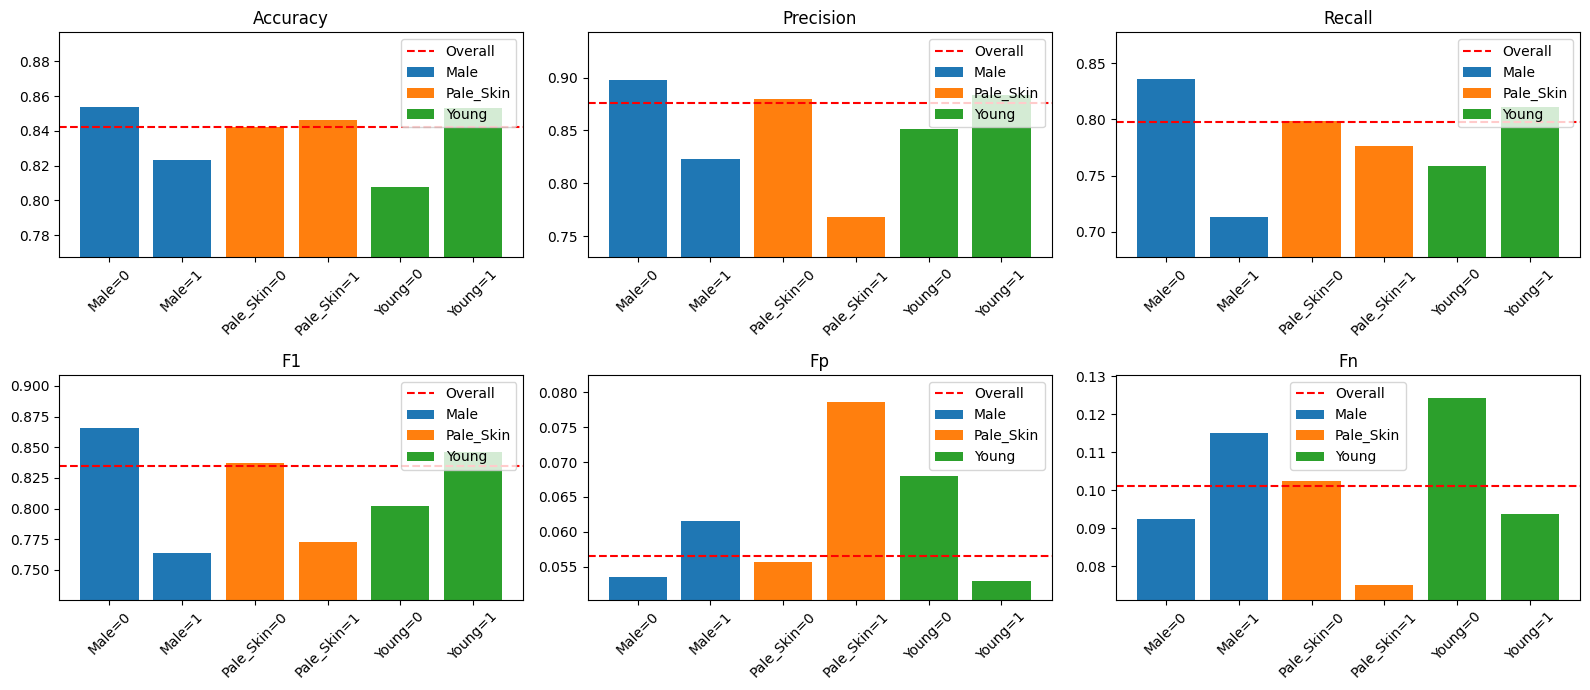

In [131]:
for group in sensitive_attr:
    print(f"Group: {group}")
    for group_value in [0, 1]:
        metrics = fairness_smiling_results[group][group_value]
        print(f"  Value: {group_value}, Accuracy: {metrics['accuracy']:.3f}, Precision: {metrics['precision']:.3f}, Recall: {metrics['recall']:.3f}, F1: {metrics['f1']:.3f}, N: {metrics['n']}, FP: {10*metrics['FP']:.3f}%, FN: {10*metrics['FN']:.3f}%")

# Plot subplots one per metric with all groups on the same plot
metrics = ["accuracy", "precision", "recall", "f1", "FP", "FN"]
fig = plt.figure(figsize=(16, 7))
axs = fig.subplots(2, 3)
axs = axs.flatten()
for i, metric in enumerate(metrics):
    ax = axs[i]
    min_y, max_y = 1, 0
    mean = 0
    for group in sensitive_attr:
        values = [fairness_smiling_results[group][0][metric], fairness_smiling_results[group][1][metric]]
        mean = values[0] * fairness_smiling_results[group][0]["n"] + values[1] * fairness_smiling_results[group][1]["n"]
        mean /= (fairness_smiling_results[group][0]["n"] + fairness_smiling_results[group][1]["n"])
        min_y, max_y = min(min_y, min(values)), max(max_y, max(values))
        ax.bar([f"{group}=0", f"{group}=1"], values, label=group)
    ax.axhline(mean, color='red', linestyle='--', label='Overall')
    ax.set_title(metric.capitalize())
    ax.set_ylim(min_y * 0.95, max_y * 1.05)
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

En conclusion, on observe que les groupes les plus représentés sont souvent aussi les plus justement classifiés:
- les femmes qui représentent 61% des données ont une accuracy de +3pts par rapport aux hommes
- les hommes souriants sont beaucoup plus souvent classés comme non souriants à tord (FN) avec 12 pts d'écart par rapport aux femmes
- de même pour les plus jeunes (qui représentent 76% de l'échantillon) gagnent +5pts par rapport aux plus âgés sur l'accuracy
- les personnes blafardes sont plus souvent classées comme souriantes à tord (FP)